# WSmart+ Route — Single-Day Optimization

This notebook performs a single-day collection route optimization using real bin state data
from the EVOX dashboard export and the Candaval depot distance matrix.

**Data sources:**
- Bin states: `data/wsr_simulator/datasets/Análise_Dashboard_EVOX_14052026.xlsx` (sheet `02Junho`)
- Distance matrix: `data/wsr_simulator/distance_matrix/Matriz_distancia_258contentores_DepotCandaval.xlsx`

**Pipeline:**
1. Load bin states and distance matrix
2. Select bins with **LookaheadMustGo** strategy (overflow today + before next collection visit)
3. Solve multi-trip CVRP with **PG-CLNS** (Pheromone-Guided Cooperative Large Neighborhood Search)
4. Automatic multi-trip splitting when collected kg exceeds vehicle capacity
5. Visualise per-trip routes and report KPIs

---
## 0 · Notebook Setup

In [1]:
from notebook_setup import setup_google_colab, setup_home_directory

NOTEBOOK_NAME = 'single_day_optimization'
home_dir = setup_home_directory(NOTEBOOK_NAME)
IN_COLAB, gdrive, gfiles = setup_google_colab(NOTEBOOK_NAME)

Setup completed - added home_dir to system path: /home/pkhunter/Repositories/WSmart-Route
Google Colab libraries not found. Are you running in a Colab notebook?


In [2]:
import os
import time
from typing import Dict, List, Optional, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Circular-import primers — must appear before any logic.src.pipeline imports
import logic.src.data.datasets  # noqa: F401
from logic.src.pipeline.simulations.actions.base import _flatten_config  # noqa: F401

from logic.src.interfaces.context.selection_context import SelectionContext
from logic.src.policies.mandatory_selection.selection_lookahead import LookaheadSelection
from logic.src.policies.route_construction.meta_heuristics.pheromone_guided_cooperative_large_neighborhood_search.params import (
    ACOParams,
    LNSParams,
    PGCLNSParams,
)
from logic.src.policies.route_construction.meta_heuristics.pheromone_guided_cooperative_large_neighborhood_search.pg_clns import (
    PGCLNSSolver,
)
from logic.src.policies.route_construction.other_algorithms.travelling_salesman_problem.tsp import get_route_cost

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

/home/pkhunter/Repositories/WSmart-Route/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set parameter Username


Set parameter Username


Set parameter LicenseID to value 2793995


Set parameter LicenseID to value 2793995


Academic license - for non-commercial use only - expires 2027-03-18


Academic license - for non-commercial use only - expires 2027-03-18


---
## 1 · Configuration

In [3]:
# ── File paths ──────────────────────────────────────────────────────────────
DATASET_PATH = os.path.join(
    home_dir, 'data', 'wsr_simulator', 'datasets',
    'Análise_Dashboard_EVOX_14052026.xlsx',
)
DATASET_SHEET = '02Junho'

DIST_MATRIX_PATH = os.path.join(
    home_dir, 'data', 'wsr_simulator', 'distance_matrix',
    'Matriz_distancia_258contentores_DepotCandaval.xlsx',
)
DIST_MATRIX_SHEET = 'matrizdistancias'

# ── Economic parameters ──────────────────────────────────────────────────────
VEHICLE_CAPACITY  = 3500.0  # kg per trip
REVENUE_PER_KG    = 1.0     # € / kg collected
COST_PER_KM       = 1.0     # € / km driven
SEED              = 42

# ── PG-CLNS solver parameters ────────────────────────────────────────────────
PGCLNS_PARAMS = PGCLNSParams(
    population_size  = 10,
    max_iterations   = 50,
    replacement_rate = 0.2,
    time_limit       = 60.0,
    aco=ACOParams(
        n_ants                 = 20,
        k_sparse               = 15,
        alpha                  = 1.0,
        beta                   = 2.0,
        rho                    = 0.1,
        q0                     = 0.9,
        max_iterations         = 1,
        time_limit             = 30.0,
        local_search           = False,
        local_search_iterations= 0,
        elitist_weight         = 1.0,
    ),
    lns=LNSParams(
        max_iterations  = 200,
        start_temp      = 100.0,
        cooling_rate    = 0.995,
        reaction_factor = 0.5,
        min_removal     = 1,
        max_removal_pct = 0.3,
        time_limit      = 30.0,
    ),
)

print(f'Vehicle capacity : {VEHICLE_CAPACITY} kg/trip')
print(f'Revenue/Cost     : €{REVENUE_PER_KG:.2f}/kg   €{COST_PER_KM:.2f}/km')
print(f'PG-CLNS          : pop={PGCLNS_PARAMS.population_size}, '
      f'iters={PGCLNS_PARAMS.max_iterations}, '
      f'time_limit={PGCLNS_PARAMS.time_limit}s')

Vehicle capacity : 3500.0 kg/trip
Revenue/Cost     : €1.00/kg   €1.00/km
PG-CLNS          : pop=10, iters=50, time_limit=60.0s


---
## 2 · Load Data

In [4]:
# ── Bin state data ───────────────────────────────────────────────────────────
raw = pd.read_excel(DATASET_PATH, sheet_name=DATASET_SHEET, header=1)

# Row 0 of the raw sheet is an extra header row — drop non-numeric Local values
raw = raw.dropna(subset=['Local'])
raw = raw[raw['Local'].apply(lambda x: str(x).replace('.0', '').isdigit())].copy()
raw['bin_id'] = raw['Local'].astype(int)

col_rename = {
    'Local'                   : 'bin_id_raw',
    '% vol. atual'            : 'fill_current',
    '% vol. média'            : 'fill_mean',
    'Acum. (%/dia)'           : 'accum_rate_pct_day',
    'Volume (kg)'             : 'volume_kg',
    'Nº Cont.'                : 'n_containers',
    'Volume do contentor (m3)': 'container_vol_m3',
    'Latitude'                : 'lat',
    'Longitude'               : 'lon',
    'Foi visitado?'           : 'visited',
    'Kg Visitados'            : 'kg_visited',
    'Kg a recolher'           : 'kg_to_collect',
    '%/Dia'                   : 'fill_rate_per_day',
    'Dias até Overflow'       : 'days_until_overflow',
    'Dia 1'                   : 'fill_day1',
    'Dia 2'                   : 'fill_day2',
    'Dia 3'                   : 'fill_day3',
    'Dia 4'                   : 'fill_day4',
    74                        : 'must_go_flag',
}
bins_df = raw.rename(columns=col_rename)[[
    'bin_id', 'fill_current', 'fill_mean', 'accum_rate_pct_day',
    'volume_kg', 'n_containers', 'container_vol_m3',
    'lat', 'lon', 'visited', 'kg_to_collect',
    'fill_rate_per_day', 'days_until_overflow', 'must_go_flag',
    'fill_day1', 'fill_day2', 'fill_day3', 'fill_day4',
]].reset_index(drop=True)

print(f'Bins loaded           : {len(bins_df)}')
print(f'Mean fill level       : {bins_df["fill_current"].mean():.1%}')
print(f'Mean accum rate       : {bins_df["accum_rate_pct_day"].mean():.2f} %/day')
bins_df.head()

Bins loaded           : 258
Mean fill level       : 44.6%
Mean accum rate       : 31.65 %/day


,bin_id,fill_current,fill_mean,accum_rate_pct_day,volume_kg,n_containers,container_vol_m3,lat,lon,visited,kg_to_collect,fill_rate_per_day,days_until_overflow,must_go_flag,fill_day1,fill_day2,fill_day3,fill_day4
0,346,1.0,0.875,35.0,70.0,2.0,2.5,39.287210,-8.886309,1.0,70.0,0.35,2.857143,MUST GO,0.0,0.35,0.7,1.05
1,348,1.0,1.000,35.0,40.0,1.0,2.5,39.254844,-8.861512,1.0,40.0,0.35,2.857143,MUST GO,0.0,0.35,0.7,1.05
2,362,1.0,1.000,35.0,40.0,1.0,2.5,39.373414,-8.891544,1.0,40.0,0.35,2.857143,MUST GO,0.0,0.35,0.7,1.05
3,366,1.0,1.000,35.0,40.0,1.0,2.5,39.390875,-8.927229,1.0,40.0,0.35,2.857143,MUST GO,0.0,0.35,0.7,1.05
4,375,1.0,1.000,35.0,40.0,1.0,2.5,39.329995,-8.923136,1.0,40.0,0.35,2.857143,MUST GO,0.0,0.35,0.7,1.05


In [5]:
# ── Distance matrix ──────────────────────────────────────────────────────────
# Index and columns are bin IDs; 0 = Candaval depot
dm_raw = pd.read_excel(
    DIST_MATRIX_PATH, sheet_name=DIST_MATRIX_SHEET, index_col=0
)
dm_raw.columns = dm_raw.columns.astype(int)
dm_raw.index   = dm_raw.index.astype(int)

# Positional list: position 0 → depot (ID 0), position i → bin ID dm_ids[i]
dm_ids = list(dm_raw.index)           # list of IDs in row order
id_to_pos: Dict[int, int] = {bid: pos for pos, bid in enumerate(dm_ids)}
dm_np = dm_raw.values.astype(float)   # shape (259, 259)

# Fill NaN entries (missing road distances) with the 95th-percentile finite distance
nan_mask = np.isnan(dm_np)
if nan_mask.any():
    fill_val = float(np.nanpercentile(dm_np, 95))
    dm_np[nan_mask] = fill_val
    print(f'Filled {nan_mask.sum()} NaN entries with {fill_val:.2f} km (95th-pct fallback)')

lat_lon_raw = pd.read_excel(
    DIST_MATRIX_PATH, sheet_name='LatLong'
).rename(columns={'id_contentor': 'bin_id', 'Latitude': 'lat_dm', 'Longitude': 'lon_dm'})

depot_row = lat_lon_raw[lat_lon_raw['bin_id'] == 0].iloc[0]
depot_lat, depot_lon = float(depot_row['lat_dm']), float(depot_row['lon_dm'])

print(f'Distance matrix shape : {dm_np.shape}  (includes depot at position 0)')
print(f'Depot (ID=0) coords   : lat={depot_lat:.6f}, lon={depot_lon:.6f}')
print(f'Min / Max distance    : {dm_np[dm_np > 0].min():.2f} / {dm_np.max():.2f} km')

Filled 490 NaN entries with 22.30 km (95th-pct fallback)
Distance matrix shape : (259, 259)  (includes depot at position 0)
Depot (ID=0) coords   : lat=39.183849, lon=-9.148065
Min / Max distance    : 0.06 / 68.72 km


---
## 3 · Bin Selection

LookaheadSelection selected : 154 mandatory bins
Total mandatory kg          : 4494.8 kg
Remaining fleet             : 104 optional bins


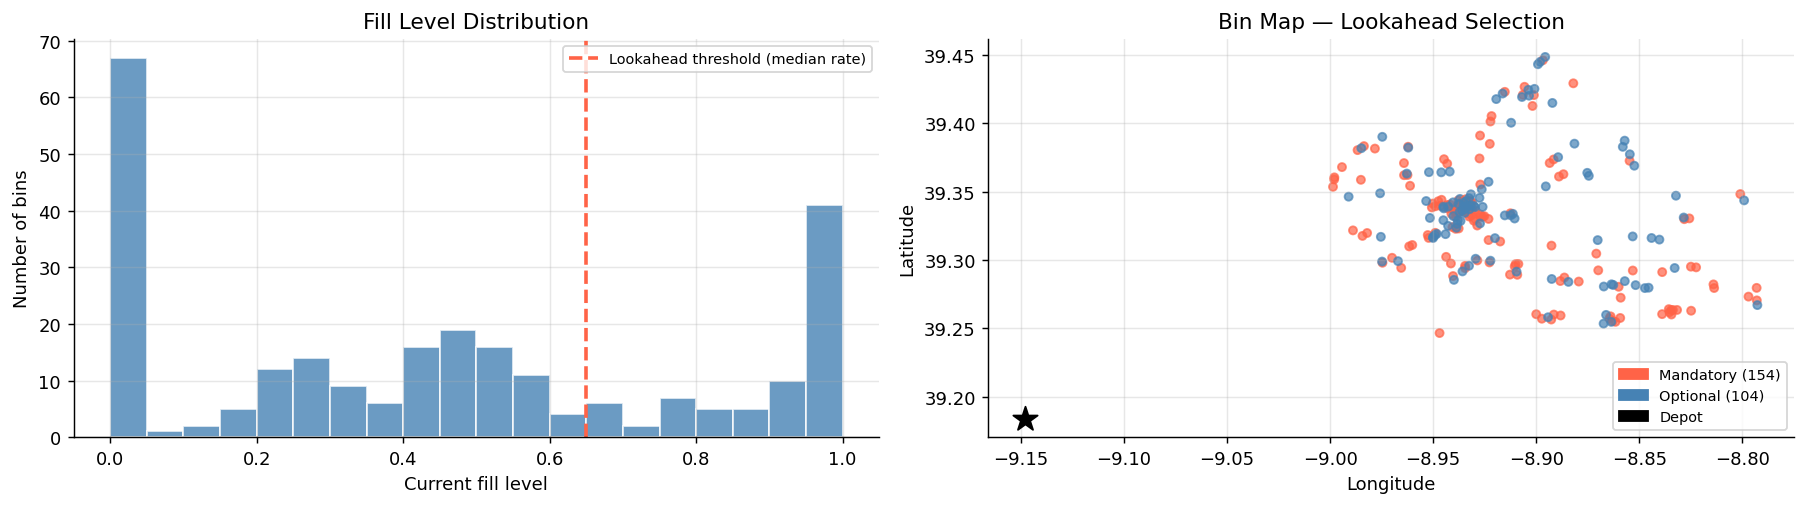

In [6]:
# ── Lookahead must-go selection ───────────────────────────────────────────────
sel_ctx = SelectionContext(
    bin_ids            = np.arange(len(bins_df), dtype=np.int32),
    current_fill       = (bins_df['fill_current'].values * 100).astype(np.float64),
    accumulation_rates = bins_df['accum_rate_pct_day'].values.astype(np.float64),
    current_collection_day = 0,
)

selected_1based, _ = LookaheadSelection().select_bins(sel_ctx)

if not selected_1based:
    raise ValueError('LookaheadSelection returned no bins. Check fill levels and accumulation rates.')

selected_rows = [bins_df.iloc[i - 1] for i in selected_1based]
selected_df   = pd.DataFrame(selected_rows).reset_index(drop=True)

print(f'LookaheadSelection selected : {len(selected_df)} mandatory bins')
print(f'Total mandatory kg          : {selected_df["kg_to_collect"].sum():.1f} kg')
print(f'Remaining fleet             : {len(bins_df) - len(selected_df)} optional bins')

# ── Sub-problem: full fleet ───────────────────────────────────────────────────
# Include the entire distance matrix so PG-CLNS can opportunistically visit
# non-mandatory bins when doing so improves the objective.
# Local indices equal global dm positions (identity mapping).
sub_idx = list(range(len(dm_ids)))   # [0, 1, ..., 258]  — depot + all 258 bins
sub_dm  = dm_np                      # full 259×259 matrix (no copy needed)

# Waste for every bin; non-mandatory bins with kg > 0 are candidates for
# opportunistic collection. Bins absent from bins_df default to 0.0 kg.
bins_kg = {int(row['bin_id']): float(row['kg_to_collect']) for _, row in bins_df.iterrows()}
sub_wastes = {
    pos: bins_kg.get(int(dm_ids[pos]), 0.0)
    for pos in range(1, len(dm_ids))   # pos 0 is depot — excluded
}

# Only the LookaheadMustGo bins are mandatory; PG-CLNS guarantees all of them
# are visited and may add further bins when profitable.
mandatory_local = [id_to_pos[int(row['bin_id'])] for row in selected_rows]

# ── Visualisation ────────────────────────────────────────────────────────────
mask_selected = bins_df['bin_id'].isin(selected_df['bin_id'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(bins_df['fill_current'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(
    (100 - bins_df['accum_rate_pct_day'].median()) / 100, color='tomato', lw=2,
    linestyle='--', label='Lookahead threshold (median rate)',
)
axes[0].set_xlabel('Current fill level'); axes[0].set_ylabel('Number of bins')
axes[0].set_title('Fill Level Distribution'); axes[0].legend(fontsize=8)

colors_scatter = ['tomato' if s else 'steelblue' for s in mask_selected]
axes[1].scatter(bins_df['lon'], bins_df['lat'], c=colors_scatter, s=20, alpha=0.7)
axes[1].scatter([depot_lon], [depot_lat], marker='*', c='black', s=200, zorder=5)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].set_title('Bin Map — Lookahead Selection')
axes[1].legend(handles=[
    mpatches.Patch(color='tomato',    label=f'Mandatory ({len(selected_df)})'),
    mpatches.Patch(color='steelblue', label=f'Optional ({(~mask_selected).sum()})'),
    mpatches.Patch(color='black',     label='Depot'),
], fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

---
## 4 · PG-CLNS Route Construction

In [7]:
print(f'Running PG-CLNS over {len(mandatory_local)} bins with capacity {VEHICLE_CAPACITY} kg/trip …')

solver = PGCLNSSolver(
    dist_matrix     = sub_dm,
    wastes          = sub_wastes,
    capacity        = VEHICLE_CAPACITY,
    R               = REVENUE_PER_KG,
    C               = COST_PER_KM,
    params          = PGCLNS_PARAMS,
    mandatory_nodes = mandatory_local,
    seed            = SEED,
)

t0 = time.perf_counter()
routes, pg_profit, pg_cost = solver.solve()
t_solve = time.perf_counter() - t0

# routes: List[List[int]] — each inner list is a single trip (local 1-based indices, no depot)
n_trips    = len(routes)
total_bins = sum(len(r) for r in routes)

print(f'PG-CLNS solved in {t_solve:.2f}s')
print(f'Trips generated   : {n_trips}')
print(f'Bins covered      : {total_bins} / {len(mandatory_local)}')
print(f'Reported profit   : {pg_profit:.2f} €')
print(f'Reported cost     : {pg_cost:.2f} km')
for i, route in enumerate(routes, 1):
    trip_kg = sum(sub_wastes.get(n, 0) for n in route)
    trip_km = get_route_cost(sub_dm, [0] + route + [0])
    print(f'  Trip {i}: {len(route)} stops, {trip_kg:.1f} kg, {trip_km:.2f} km')

Running PG-CLNS over 154 bins with capacity 3500.0 kg/trip …


PG-CLNS solved in 181.31s
Trips generated   : 2
Bins covered      : 212 / 154
Reported profit   : 4550.18 €
Reported cost     : 325.82 km
  Trip 1: 142 stops, 3400.4 kg, 225.21 km
  Trip 2: 70 stops, 1475.6 kg, 100.61 km


---
## 5 · Results & KPIs

In [8]:
# Build per-trip DataFrames with actual bin IDs and global distances
trip_records = []
for trip_num, route in enumerate(routes, 1):
    trip_km   = get_route_cost(sub_dm, [0] + route + [0])
    trip_kg   = sum(sub_wastes.get(n, 0) for n in route)
    trip_bins = [dm_ids[sub_idx[local_i]] for local_i in route]  # actual bin IDs
    trip_records.append({
        'trip'   : trip_num,
        'n_stops': len(route),
        'kg'     : round(trip_kg, 1),
        'km'     : round(trip_km, 2),
        'kg/km'  : round(trip_kg / trip_km, 3) if trip_km > 0 else 0.0,
        'bin_ids': trip_bins,
    })

trips_df = pd.DataFrame(trip_records)
print('=== Per-Trip Summary ===')
display(trips_df[['trip', 'n_stops', 'kg', 'km', 'kg/km']])

# Flat route: all trips stitched as depot-separated sequence
flat_route_global = []  # bin IDs in visit order (depot=0 between trips)
for rec in trip_records:
    flat_route_global += [0] + rec['bin_ids']
flat_route_global += [0]

=== Per-Trip Summary ===


,trip,n_stops,kg,km,kg/km
0,1,142,3400.4,225.21,15.099
1,2,70,1475.6,100.61,14.666


---
## 6 · Day KPIs

In [9]:
total_km  = trips_df['km'].sum()
total_kg  = trips_df['kg'].sum()
total_col = int(trips_df['n_stops'].sum())
kg_per_km = total_kg / total_km if total_km > 0 else 0.0
net_profit = REVENUE_PER_KG * total_kg - COST_PER_KM * total_km

kpis = {
    'km'        : round(total_km, 2),
    'kg'        : round(total_kg, 2),
    'ncol'      : total_col,
    'trips'     : n_trips,
    'kg/km'     : round(kg_per_km, 3),
    'profit (€)': round(net_profit, 2),
}

kpis_df = pd.DataFrame([kpis]).T.rename(columns={0: 'value'})
print('=== Day KPIs ===')
display(kpis_df)

=== Day KPIs ===


,value
km,325.820
kg,4876.000
ncol,212.000
trips,2.000
kg/km,14.965
profit (€),4550.180


In [10]:
# Bin-level breakdown across all trips
detail_rows = []
global_stop = 0
for rec in trip_records:
    cum_km = 0.0
    prev_dm_pos = 0  # depot
    for bin_id in rec['bin_ids']:
        global_stop += 1
        dm_pos   = id_to_pos[bin_id]
        cum_km  += sub_dm[sub_idx.index(prev_dm_pos), sub_idx.index(dm_pos)]
        bin_row  = bins_df[bins_df['bin_id'] == bin_id].iloc[0]
        detail_rows.append({
            'trip'              : rec['trip'],
            'stop'              : global_stop,
            'bin_id'            : bin_id,
            'fill_current_pct'  : round(float(bin_row['fill_current']) * 100, 1),
            'kg_to_collect'     : float(bin_row['kg_to_collect']),
            'days_until_overflow': float(bin_row['days_until_overflow']) if pd.notna(bin_row['days_until_overflow']) else None,
            'cum_km'            : round(cum_km, 2),
        })
        prev_dm_pos = dm_pos

route_detail = pd.DataFrame(detail_rows)
print(f'Optimised route — {len(route_detail)} stops across {n_trips} trips')
display(route_detail[['trip','stop','bin_id','fill_current_pct',
                       'kg_to_collect','days_until_overflow','cum_km']].to_string(index=False))

Optimised route — 212 stops across 2 trips


' trip  stop  bin_id  fill_current_pct  kg_to_collect  days_until_overflow  cum_km\n    1     1    5656              54.0           21.6             2.857143   27.04\n    1     2    3563              83.0           33.2             2.857143   33.51\n    1     3    1433              90.0           56.0             2.857143   34.01\n    1     4     347              99.0           39.6             2.857143   34.45\n    1     5    2350              45.0           18.0             2.857143   35.00\n    1     6    7653              96.0           38.4             2.857143   35.44\n    1     7    9766              46.0           18.4             2.857143   38.20\n    1     8    2726              54.0           21.6             2.857143   38.43\n    1     9    3630              52.0           20.8             2.857143   38.84\n    1    10     348             100.0           40.0             2.857143   39.07\n    1    11    2069              58.0           23.2             2.857143   39.49\n   

---
## 7 · Route Visualisation

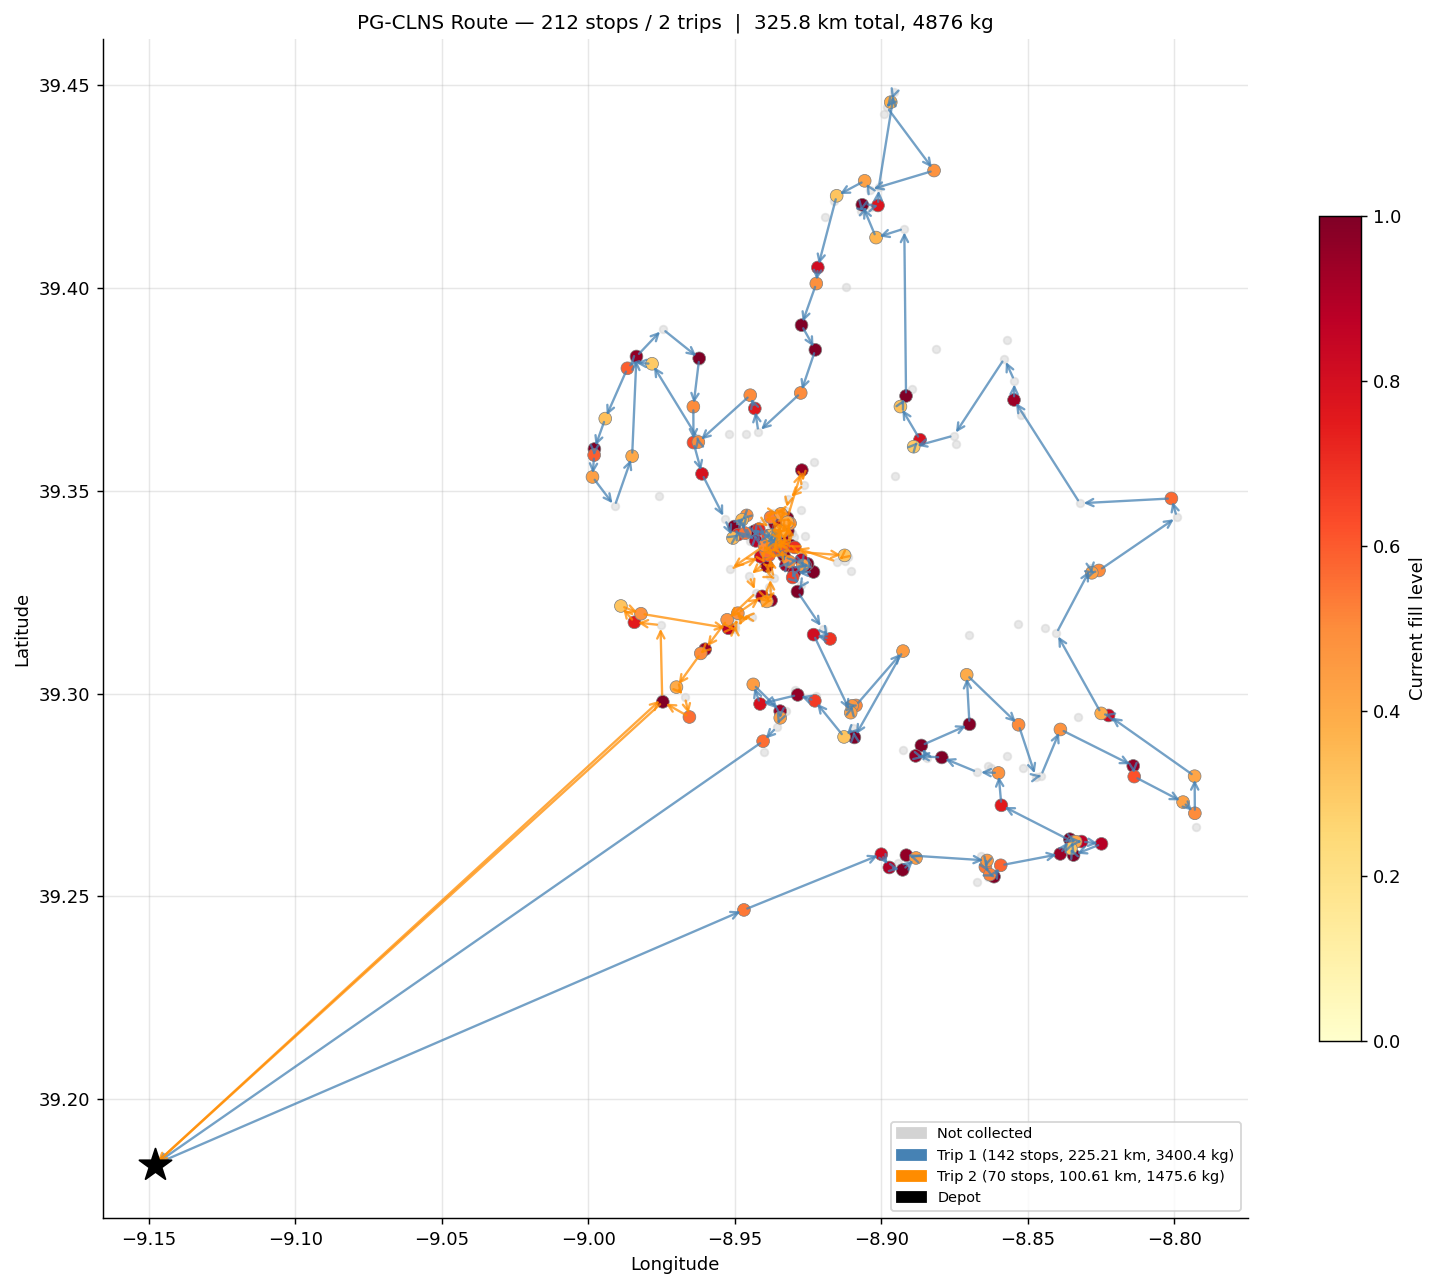

In [11]:
# Build lat/lon lookup
coords: Dict[int, Tuple[float, float]] = {
    int(row['bin_id']): (float(row['lat']), float(row['lon']))
    for _, row in bins_df.iterrows()
    if pd.notna(row['lat'])
}
coords[0] = (depot_lat, depot_lon)

TRIP_COLORS = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato',
               'mediumpurple', 'saddlebrown', 'deeppink', 'teal']

fig, ax = plt.subplots(figsize=(12, 10))

# Background bins not collected
not_sel = bins_df[~mask_selected]
ax.scatter(not_sel['lon'], not_sel['lat'],
           c='lightgrey', s=18, alpha=0.5, label='Not collected', zorder=2)

# Selected bins coloured by fill level
sc = ax.scatter(
    selected_df['lon'], selected_df['lat'],
    c=selected_df['fill_current'], cmap='YlOrRd', vmin=0, vmax=1,
    s=50, zorder=3, edgecolors='grey', linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label='Current fill level', shrink=0.7)

# Depot
ax.scatter([depot_lon], [depot_lat], marker='*', c='black', s=350, zorder=6)

# Draw each trip with its own colour
legend_patches = [mpatches.Patch(color='lightgrey', label='Not collected')]
for rec in trip_records:
    color = TRIP_COLORS[(rec['trip'] - 1) % len(TRIP_COLORS)]
    full_trip = [0] + rec['bin_ids'] + [0]
    for a_id, b_id in zip(full_trip[:-1], full_trip[1:]):
        if a_id in coords and b_id in coords:
            a_lat, a_lon = coords[a_id]
            b_lat, b_lon = coords[b_id]
            ax.annotate(
                '', xy=(b_lon, b_lat), xytext=(a_lon, a_lat),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3, alpha=0.75),
            )
    legend_patches.append(
        mpatches.Patch(color=color,
                       label=f'Trip {rec["trip"]} ({rec["n_stops"]} stops, {rec["km"]} km, {rec["kg"]} kg)')
    )

legend_patches.append(mpatches.Patch(color='black', label='Depot'))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    f'PG-CLNS Route — {total_col} stops / {n_trips} trips  |  '
    f'{total_km:.1f} km total, {total_kg:.0f} kg',
    fontsize=11,
)
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

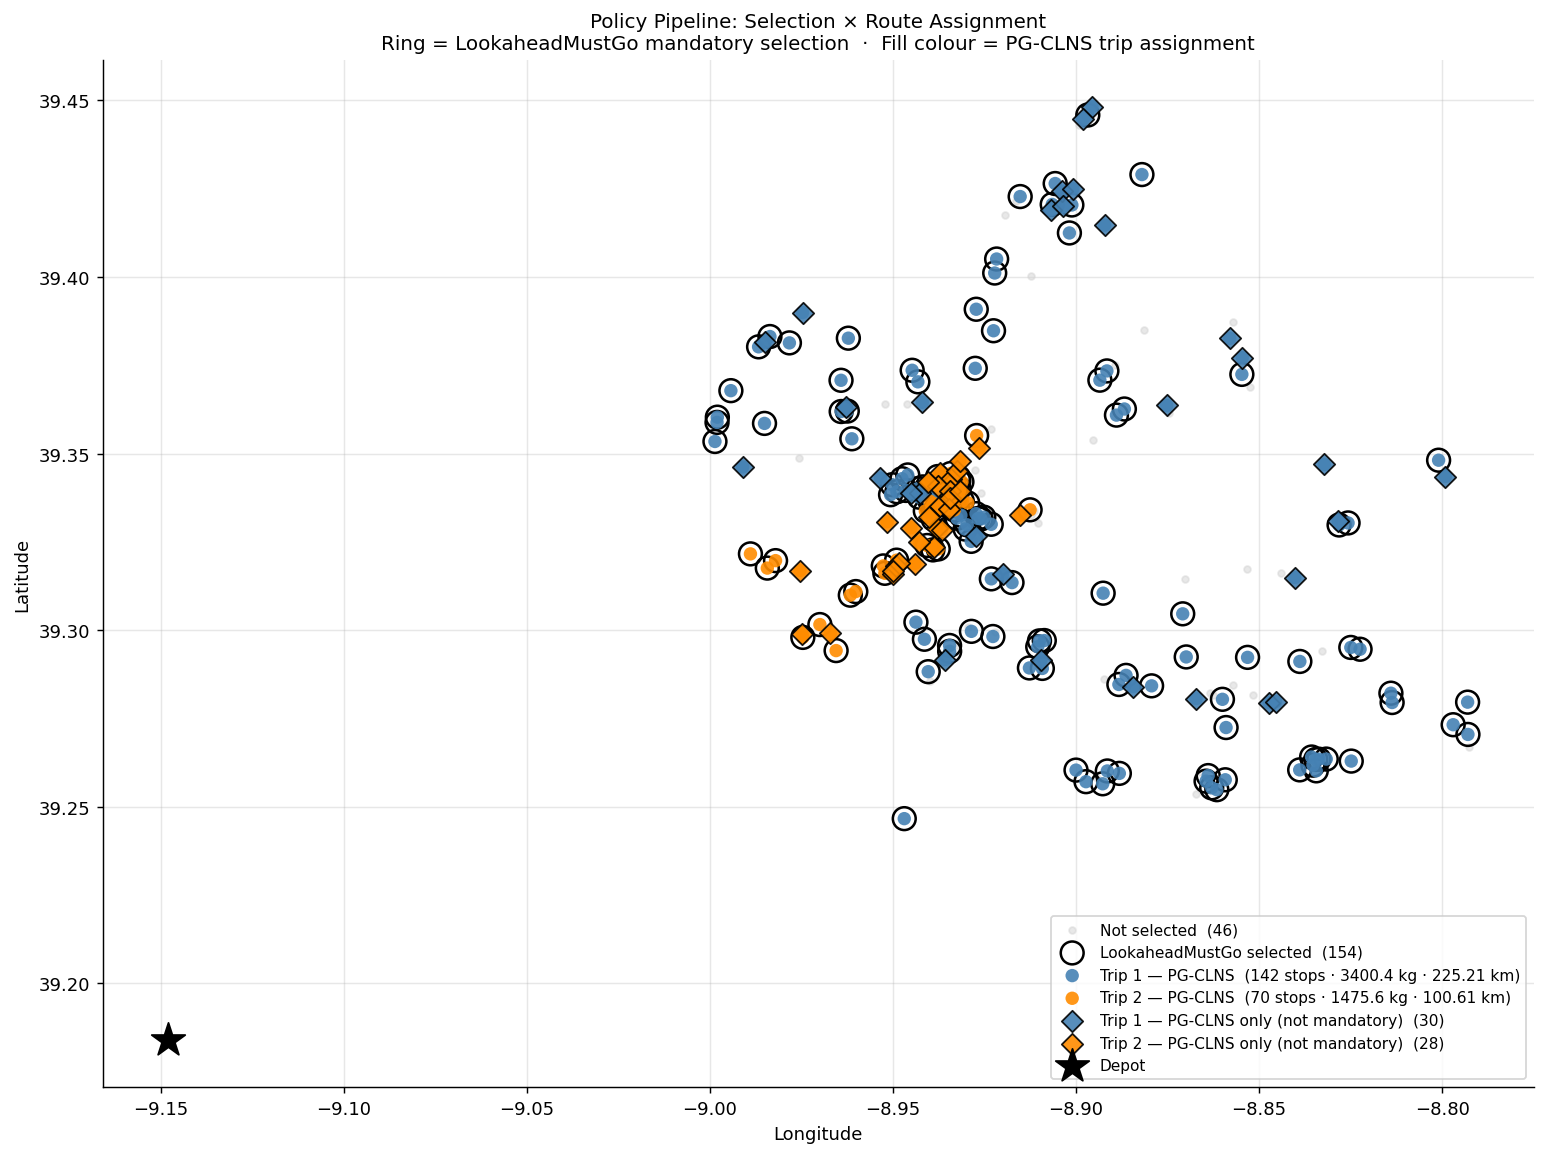

In [12]:
# ── Selection stage vs route assignment ──────────────────────────────────────
# Build bin_id → trip_number lookup from the route constructor output
trip_bin_map: Dict[int, int] = {}
for rec in trip_records:
    for bid in rec['bin_ids']:
        trip_bin_map[bid] = rec['trip']

# Bins chosen by LookaheadSelection but absent from all routes (edge case)
unrouted_ids = set(selected_df['bin_id']) - set(trip_bin_map.keys())

# Bins placed in a route by PG-CLNS but NOT flagged by mandatory selection
# (would appear if the solver adds opportunistic stops beyond mandatory_nodes)
constructor_only_ids = set(trip_bin_map.keys()) - set(selected_df['bin_id'])

fig, ax = plt.subplots(figsize=(12, 9))

# ── Layer 1: bins not touched by either stage ─────────────────────────────────
not_sel = bins_df[~mask_selected & ~bins_df['bin_id'].isin(constructor_only_ids)]
ax.scatter(
    not_sel['lon'], not_sel['lat'],
    c='lightgrey', s=14, alpha=0.5, zorder=2,
    label=f'Not selected  ({len(not_sel)})',
)

# ── Layer 2: mandatory-selection ring (LookaheadMustGo) ───────────────────────
# A hollow ring is drawn around every bin the mandatory selector flagged.
# Applies to both in-route and unrouted mandatory bins.
all_mandatory = selected_df.copy()
ax.scatter(
    all_mandatory['lon'], all_mandatory['lat'],
    facecolors='none', edgecolors='black', linewidths=1.4,
    s=160, zorder=3,
    label=f'LookaheadMustGo selected  ({len(all_mandatory)})',
)

# ── Layer 3: route-constructor fill (PG-CLNS) ─────────────────────────────────
# A solid filled dot inside each ring shows which trip PG-CLNS assigned the bin to.
for rec in trip_records:
    trip_num = rec['trip']
    color    = TRIP_COLORS[(trip_num - 1) % len(TRIP_COLORS)]
    trip_ids = set(rec['bin_ids'])
    trip_pts = bins_df[bins_df['bin_id'].isin(trip_ids)]
    ax.scatter(
        trip_pts['lon'], trip_pts['lat'],
        c=color, s=55, alpha=0.9, zorder=4, edgecolors='none',
        label=(
            f'Trip {trip_num} — PG-CLNS  '
            f'({rec["n_stops"]} stops · {rec["kg"]} kg · {rec["km"]} km)'
        ),
    )

# ── Layer 4: constructor-only bins (opportunistic, not mandatory) ──────────────
if constructor_only_ids:
    con_pts = bins_df[bins_df['bin_id'].isin(constructor_only_ids)]
    trip_num_map = {bid: trip_bin_map[bid] for bid in constructor_only_ids}
    for trip_num in sorted(set(trip_num_map.values())):
        color   = TRIP_COLORS[(trip_num - 1) % len(TRIP_COLORS)]
        sub_ids = {b for b, t in trip_num_map.items() if t == trip_num}
        sub_pts = con_pts[con_pts['bin_id'].isin(sub_ids)]
        ax.scatter(
            sub_pts['lon'], sub_pts['lat'],
            c=color, marker='D', s=70, alpha=0.9, zorder=4, edgecolors='black', linewidths=1.0,
            label=f'Trip {trip_num} — PG-CLNS only (not mandatory)  ({len(sub_pts)})',
        )

# ── Layer 5: mandatory bins the solver failed to route ───────────────────────
if unrouted_ids:
    unr_pts = bins_df[bins_df['bin_id'].isin(unrouted_ids)]
    ax.scatter(
        unr_pts['lon'], unr_pts['lat'],
        c='red', s=90, marker='x', linewidths=2.5, zorder=5,
        label=f'Mandatory but not routed  ({len(unrouted_ids)})',
    )

# ── Depot ─────────────────────────────────────────────────────────────────────
ax.scatter([depot_lon], [depot_lat], marker='*', c='black', s=380, zorder=6, label='Depot')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    'Policy Pipeline: Selection × Route Assignment\n'
    'Ring = LookaheadMustGo mandatory selection  ·  Fill colour = PG-CLNS trip assignment',
    fontsize=11,
)
ax.legend(fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.show()

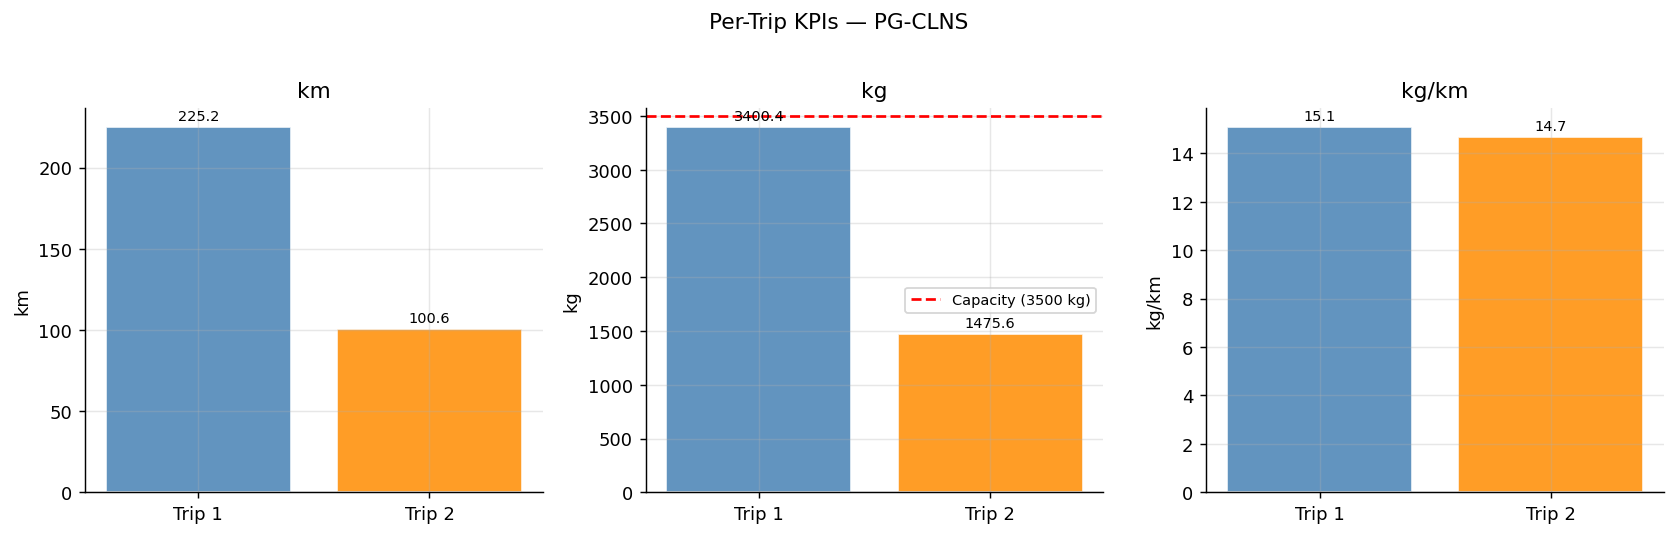

In [13]:
# ── Per-trip KPI bar chart ───────────────────────────────────────────────────
metrics_to_plot = ['km', 'kg', 'kg/km']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(13, 4))

trip_labels = [f'Trip {r["trip"]}' for r in trip_records]
colors = [TRIP_COLORS[(r['trip'] - 1) % len(TRIP_COLORS)] for r in trip_records]

for ax, metric in zip(axes, metrics_to_plot):
    values = [r[metric] for r in trip_records]
    bars = ax.bar(trip_labels, values, color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    if len(trip_labels) > 4:
        ax.set_xticklabels(trip_labels, rotation=30, ha='right', fontsize=8)

# Add capacity reference line to kg plot
axes[1].axhline(VEHICLE_CAPACITY, color='red', lw=1.5, linestyle='--',
                label=f'Capacity ({VEHICLE_CAPACITY:.0f} kg)')
axes[1].legend(fontsize=8)

plt.suptitle('Per-Trip KPIs — PG-CLNS', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

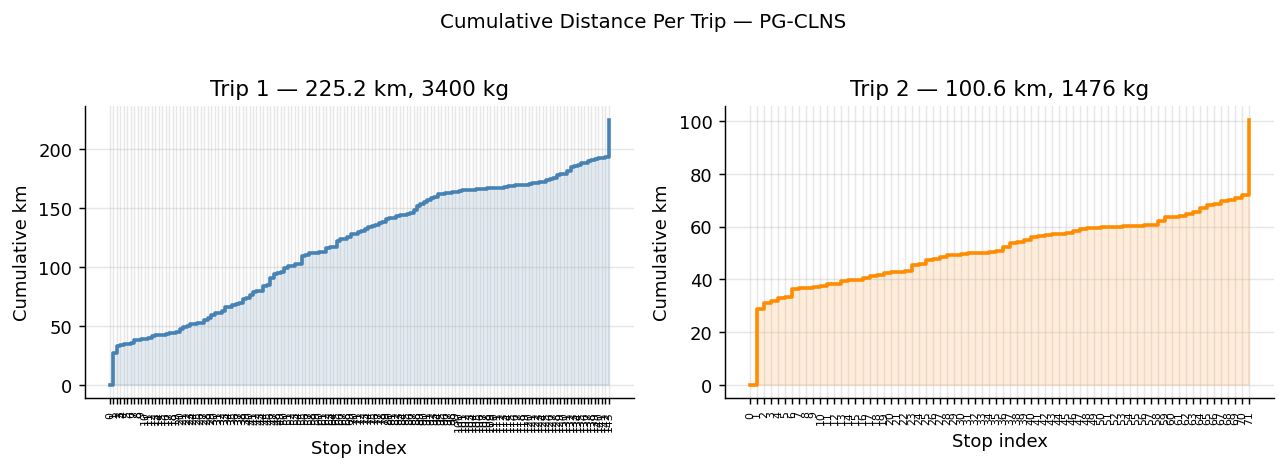

In [14]:
# ── Cumulative distance per trip ─────────────────────────────────────────────
fig, axes = plt.subplots(1, n_trips, figsize=(max(6, 5 * n_trips), 3.5), squeeze=False)

for ax, rec in zip(axes[0], trip_records):
    color = TRIP_COLORS[(rec['trip'] - 1) % len(TRIP_COLORS)]
    route_local = routes[rec['trip'] - 1]
    trip_seq    = [0] + route_local + [0]

    cum = [0.0]
    for a, b in zip(trip_seq[:-1], trip_seq[1:]):
        cum.append(cum[-1] + sub_dm[a, b])

    ax.step(range(len(cum)), cum, color=color, lw=2, where='post')
    ax.fill_between(range(len(cum)), cum, alpha=0.15, color=color, step='post')
    ax.set_title(f'Trip {rec["trip"]} — {rec["km"]:.1f} km, {rec["kg"]:.0f} kg')
    ax.set_xlabel('Stop index')
    ax.set_ylabel('Cumulative km')
    ax.set_xticks(range(len(cum)))
    ax.set_xticklabels(range(len(cum)), fontsize=6, rotation=90)

plt.suptitle('Cumulative Distance Per Trip — PG-CLNS', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 8 · Fill-Level Forecast for Non-Collected Bins

Non-collected bins        : 104
  Overflow within 1 day   : 0
  Overflow within 2–3 days: 56


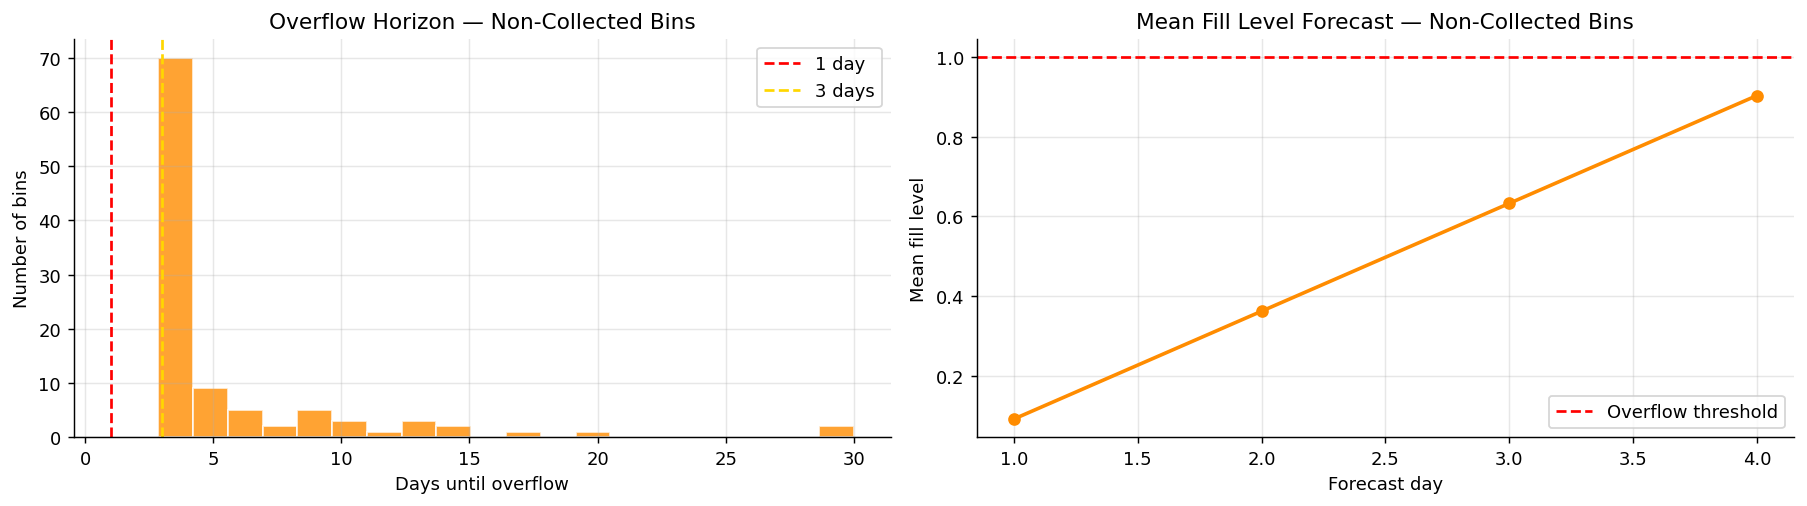

In [15]:
# Bins not collected today — show predicted overflow timeline
not_collected_df = bins_df[~mask_selected].copy()
not_collected_df = not_collected_df[not_collected_df['days_until_overflow'].notna()]

overflow_1d = not_collected_df[not_collected_df['days_until_overflow'] <= 1]
overflow_3d = not_collected_df[
    (not_collected_df['days_until_overflow'] > 1) &
    (not_collected_df['days_until_overflow'] <= 3)
]

print(f'Non-collected bins        : {len(not_collected_df)}')
print(f'  Overflow within 1 day   : {len(overflow_1d)}')
print(f'  Overflow within 2–3 days: {len(overflow_3d)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

days_vals = not_collected_df['days_until_overflow'].clip(upper=30)
axes[0].hist(days_vals, bins=20, color='darkorange', alpha=0.8, edgecolor='white')
axes[0].axvline(1, color='red', lw=1.5, linestyle='--', label='1 day')
axes[0].axvline(3, color='gold', lw=1.5, linestyle='--', label='3 days')
axes[0].set_xlabel('Days until overflow'); axes[0].set_ylabel('Number of bins')
axes[0].set_title('Overflow Horizon — Non-Collected Bins')
axes[0].legend()

day_cols = ['fill_day1', 'fill_day2', 'fill_day3', 'fill_day4']
available_cols = [c for c in day_cols if c in not_collected_df.columns]
if available_cols:
    means = not_collected_df[available_cols].mean()
    days  = [1, 2, 3, 4][:len(available_cols)]
    axes[1].plot(days, means.values, marker='o', color='darkorange', lw=2)
    axes[1].axhline(1.0, color='red', lw=1.5, linestyle='--', label='Overflow threshold')
    axes[1].set_xlabel('Forecast day'); axes[1].set_ylabel('Mean fill level')
    axes[1].set_title('Mean Fill Level Forecast — Non-Collected Bins')
    axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9 · Summary

In [16]:
print('=' * 58)
print('  WSmart+ Route — Single-Day Optimization Summary')
print('=' * 58)
print(f'  Date / dataset  : 02 June 2026 (EVOX 14-05-2026)')
print(f'  Total bins      : {len(bins_df)}')
print(f'  Selection       : LookaheadMustGo')
print(f'  Bins selected   : {len(selected_df)}  ({len(selected_df)/len(bins_df)*100:.1f}% of fleet)')
print(f'  Solver          : PG-CLNS (no route improver)')
print(f'  Vehicle cap.    : {VEHICLE_CAPACITY:.0f} kg/trip')
print()
print(f'  Trips           : {n_trips}')
print(f'  Total distance  : {total_km:>8.2f} km')
print(f'  Waste collected : {total_kg:>8.1f} kg')
print(f'  Efficiency      : {kg_per_km:>8.3f} kg/km')
print(f'  Profit (net)    : {net_profit:>8.2f} €')
print(f'  Solve time      : {t_solve:.2f}s')
print()
for rec in trip_records:
    print(f'  Trip {rec["trip"]:>2}: {rec["n_stops"]:>3} stops, '
          f'{rec["kg"]:>7.1f} kg / {VEHICLE_CAPACITY:.0f} kg cap, '
          f'{rec["km"]:>7.2f} km')
print('=' * 58)

  WSmart+ Route — Single-Day Optimization Summary
  Date / dataset  : 02 June 2026 (EVOX 14-05-2026)
  Total bins      : 258
  Selection       : LookaheadMustGo
  Bins selected   : 154  (59.7% of fleet)
  Solver          : PG-CLNS (no route improver)
  Vehicle cap.    : 3500 kg/trip

  Trips           : 2
  Total distance  :   325.82 km
  Waste collected :   4876.0 kg
  Efficiency      :   14.965 kg/km
  Profit (net)    :  4550.18 €
  Solve time      : 181.31s

  Trip  1: 142 stops,  3400.4 kg / 3500 kg cap,  225.21 km
  Trip  2:  70 stops,  1475.6 kg / 3500 kg cap,  100.61 km
